<a href="https://colab.research.google.com/github/cer-es/quantum-computing-intro/blob/main/lesson1_Qiskit_statevectors_and_operators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Basics of Quantum Information (Quantum Computing with Qiskit) — Lesson 1: Single systems
### 📘 Based on the IBM Quantum Learning Course

> **Course Credit:**  
This notebook is a study and exploration of concepts from the official IBM Quantum course:  
👉 **[Basics of Quantum Information](https://learning.quantum.ibm.com/course/basics-of-quantum-information)**
All educational content and theoretical background are credited to IBM Quantum and Qiskit, under the **[Apache 2.0 License](https://www.apache.org/licenses/LICENSE-2.0)**.

---

## 👩‍💻 Author Information

- **Full Name:** Imene Belkorchia  
- **Country:** Algeria 🇩🇿  
- **Academic Background:** Master’s student in Embedded Systems Electronics  
- **Specializations:**  
  - Embedded AI Systems  
  - Digital Electronics & PCB Design  
  - Python, MATLAB, Computer Vision  
  - Currently exploring Quantum Computing and Qiskit  
- **Goal:** Building a solid foundation in quantum computing and sharing my learning path with the tech community.

---

## 🎯 Notebook Objective

This notebook explores:
- Quantum state representation using **statevectors**
- Simulation of **measurements** and **unitary transformations**
- Building and evolving a **QuantumCircuit**
- Simulating measurement outcomes with `Statevector.sample_counts`

It serves as my **first milestone** in the journey toward understanding quantum computing with Qiskit and publishing open-source educational materials on Kaggle and GitHub.

---

## 📅 Date Created: April 2025


## **🧠 Quantum Gate Compositions in Qiskit:**



### **Why Use Qiskit's Built-in Tools?**


---


Instead of writing raw code to simulate state vectors, measurements, and gates using just NumPy, Qiskit offers high-level objects like:


*   Statevector – to represent quantum states.
*   Built-in methods for display, validation, and manipulation of quantum states.

### **1. Install and Check Qiskit Version**
---
Qiskit is a fast-evolving library, and checking the installed version helps ensure compatibility with the code you're running.

In [1]:
!pip install qiskit --quiet

from qiskit import __version__
print("Qiskit version:", __version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 2.9 MB/s eta 0:00:00
Qiskit version: 2.0.0


### **2. Implementing the Operation:**


---

𝑅=𝐻⋅𝑆⋅𝐻

We define a quantum circuit that applies:

**Hadamard gate (H)**

**Phase gate (S)**

**Another Hadamard gate (H)**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Qiskit version: 2.0.0


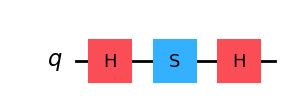

In [2]:
# ✅ Step 1: Install required libraries
!pip install qiskit pylatexenc --quiet

# ✅ Step 2: Import modules and check version
from qiskit import __version__, QuantumCircuit
import matplotlib.pyplot as plt

print("Qiskit version:", __version__)

# ✅ Step 3: Create and visualize the quantum circuit
qc = QuantumCircuit(1)

# Apply Hadamard → S → Hadamard
qc.h(0)
qc.s(0)
qc.h(0)

# Draw the circuit using Matplotlib
qc.draw('mpl')


📝 **Note**: This circuit defines the operation \( R = HSH \), which is unitary and interesting due to its relation to the NOT gate.

### **3. Apply the Operation *R* to Initial State |0⟩:**
---

We analyze how the quantum state changes after applying the gate *R*.



In [3]:
from qiskit.quantum_info import Statevector

# Define initial state |0⟩
initial_state = Statevector.from_label('0')

# Evolve the state using the circuit
final_state = initial_state.evolve(qc)

# Display resulting quantum state
print("Final quantum state after applying R = HSH:")
print(final_state)

Final quantum state after applying R = HSH:
Statevector([0.5+0.5j, 0.5-0.5j],
            dims=(2,))


### **4. Apply 𝑅² : Check if it Equals NOT Gate (X):**


---


We apply the same gate sequence **twice**, and expect it to behave like the NOT gate:

In [4]:
# Create a new circuit for R · R
qc2 = QuantumCircuit(1)

# Apply R = HSH twice
for _ in range(2):
    qc2.h(0)
    qc2.s(0)
    qc2.h(0)

# Evolve the initial state through R^2
final_state2 = Statevector.from_label('0').evolve(qc2)

# Display the result
print("State after applying R twice (R^2):")
print(final_state2)

State after applying R twice (R^2):
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


🧠 **Expected Result**:
```
Statevector([0.+0.j, 1.+0.j], dims=(2,))
```
Which corresponds to |1⟩. This confirms that   **𝑅²= X**   — the **NOT gate**!

In [5]:
import numpy as np

# Define Hadamard gate matrix
H = (1/np.sqrt(2)) * np.array([[1, 1],
                               [1, -1]])

# Define Phase (S) gate matrix
S = np.array([[1, 0],
              [0, 1j]])

# Compute R = H @ S @ H
R = H @ S @ H

# Display the resulting matrix
print("Matrix R = H * S * H:\n", R)

# Optional: Verify if R squared is the X gate (NOT gate)
X = np.array([[0, 1],
              [1, 0]])

R_squared = R @ R
print("\nR squared (R @ R):\n", R_squared)
print("\nIs R squared equal to X (NOT gate)?", np.allclose(R_squared, X))


Matrix R = H * S * H:
 [[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]

R squared (R @ R):
 [[0.-2.46519033e-32j 1.+0.00000000e+00j]
 [1.+0.00000000e+00j 0.+2.46519033e-32j]]

Is R squared equal to X (NOT gate)? True


**🔍 Explanation:**


We use `@` to perform matrix multiplication `(H @ S @ H)`.


The result `R` is a unitary matrix that represents the square root of the NOT gate.


The final check with `np.allclose()` compares `𝑅²` to the `X gate` to verify correctness.



## **🧮 Vectors and Matrices in Python (for Qiskit Users):**

Quantum computing involves a lot of linear algebra, including operations on vectors and matrices. Before diving deep into Qiskit, it's essential to understand how Python (specifically NumPy) handles these computations.



### **1. Import NumPy**


---

NumPy is Python’s core library for numerical operations. We’ll use it to define vectors, matrices, and perform matrix arithmetic.

In [6]:
import numpy as np


### **2. Defining Qubit State Vectors ∣0⟩ and ∣1⟩**


---


A single qubit can be in states ∣0⟩ = [1, 0] or ∣1⟩ = [0, 1]. These are defined as column vectors.

In [7]:
# Define ket |0⟩ and |1⟩
ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

# Compute their average
average_ket = ket0 / 2 + ket1 / 2
print("Average state of |0⟩ and |1⟩:")
print(average_ket)


Average state of |0⟩ and |1⟩:
[[0.5]
 [0.5]]


### **3. Creating and Adding Matrices**


---


You can create 2×2 matrices, representing basic quantum operations or custom transformations.

In [8]:
# Define two matrices
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])

# Average of M1 and M2
M = M1 / 2 + M2 / 2
print("Matrix M:")
print(M)


Matrix M:
[[1.  0.5]
 [0.  0.5]]


### **4. Matrix Multiplication in NumPy:**


---


Matrix multiplication is performed using `np.matmul()`.

In [9]:
# Matrix-vector multiplication
print("M1 · |1⟩:")
print(np.matmul(M1, ket1))

# Matrix-matrix multiplication
print("M1 · M2:")
print(np.matmul(M1, M2))

print("M · M:")
print(np.matmul(M, M))


M1 · |1⟩:
[[1]
 [0]]
M1 · M2:
[[1 1]
 [0 0]]
M · M:
[[1.   0.75]
 [0.   0.25]]


### **5. Visualizing with Qiskit (Pretty LaTeX Format):**


---


To improve readability of vector/matrix outputs, Qiskit provides `array_to_latex()`.

In [10]:
from qiskit.visualization import array_to_latex
from IPython.display import display

# Display results in LaTeX format
display(array_to_latex(np.matmul(M1, ket1)))
display(array_to_latex(np.matmul(M1, M2)))
display(array_to_latex(np.matmul(M, M)))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

📌 This will render the matrices beautifully in LaTeX (only visible in notebooks or Jupyter environments like Colab).

### **📌 Notes**
All operations are linear algebra based, essential for simulating quantum circuits.

Matrix-vector multiplication simulates applying a quantum gate to a state.

NumPy + Qiskit is the standard combo for quantum programming in Python.


### **📎 Summary:**


---

| **Concept** | **Python/NumPy Tool** |
|--------|---------|
| Vectors (∣0⟩, ∣1⟩) | `np.array([[1], [0]])` |
| Matrices | `np.array([[a, b], [c, d]])` |
| Matrix multiplication | `np.matmul(A, B)` |
| Visualization | `qiskit.visualization.array_to_latex()` |

---



## **⚛️ Quantum States, Measurements, and Operations in Qiskit:**

In this section, you'll learn how Qiskit provides ready-to-use tools to define quantum states, simulate operations, and handle measurements — without manually implementing quantum math from scratch.

### **1. Import Required Libraries:**


---


We need:


*   ``Statevector`` from ``qiskit.quantum_info`` for handling quantum states.
*   ``sqrt`` from NumPy to normalize state vectors.


In [11]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

### **2. Defining Quantum State Vectors:**


---


We define three quantum states here:

*   `u` is an equal superposition state.

*   `v` is a complex-valued state.

*   `w` is a non-normalized state (invalid quantum state).



In [12]:
# Define quantum states using Statevector
u = Statevector([1 / sqrt(2), 1 / sqrt(2)])            # Valid normalized state
v = Statevector([(1 + 2.0j) / 3, -2 / 3])              # Complex state
w = Statevector([1 / 3, 2 / 3])                        # Not normalized (invalid)

**📌 Note:** Quantum states must be unit vectors (norm = 1). Qiskit checks this using ` .is_valid() `.

### **3. Displaying State Vectors:**


---


We can visualize states in multiple formats:

*   `"text":` Shows real/complex numbers.

*   `"latex":` Pretty rendered quantum notation.

*   `"latex_source":` Shows raw LaTeX for use in papers or reports.

In [13]:
# Display state 'u' in different formats
display(u.draw("text"))         # Simple vector
display(u.draw("latex"))        # Rendered LaTeX
print(u.draw("latex_source"))   # Raw LaTeX source for copying

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


### **4. Validating State Vectors:**


---


`Use is_valid()` to check if a state vector is normalized (i.e., a valid quantum state).

In [14]:
display(u.is_valid())   # Expected: True
display(w.is_valid())   # Expected: False (not normalized)

True

False

### **📎 Summary:**


---


| Function | Description |
|--------|---------|
| `Statevector([...])` | Creates a quantum state vector |
| `.draw("text")` | Shows numerical vector |
| `.draw("latex")` | Shows LaTeX-rendered quantum notation |
| `.draw("latex_source")` | Gives raw LaTeX for export |
| `.is_valid()` | Checks if the state is normalized |

---

## **🎯 Simulating Measurements with Qiskit’s Statevector Class**

In this lesson, we’ll learn how to **simulate quantum measurements** using the `measure()` and `sample_counts()` methods provided by Qiskit’s `Statevector` class.


### **📌 Pre-requisites**


---


Make sure you have the following imports:


In [15]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from numpy import sqrt

### **1. Display the State Vector:**


---

Let’s visualize the quantum state v using the LaTeX format:

In [16]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

### **2. Simulating a Measurement:**


---


To simulate a quantum measurement in the computational basis (|0⟩ and |1⟩), we use the .measure() method.

In [17]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

**📌 Note:**

The outcome is randomly chosen based on the probabilities derived from **the state vector amplitudes**.

The post-measurement state is updated (collapsed) accordingly.

Even though we see ` -|1⟩ ` , it's physically equivalent to `|1⟩` (this is due to a global phase, which has no observable effect).

### **3. Invalid State Vectors:**


---


If you attempt to measure an invalid (non-normalized) state vector, Qiskit will raise an error:


In [18]:
w = Statevector([1/3, 2/3])  # Invalid (not normalized)
# w.measure()  # Uncommenting this will throw an error!

**Always ensure the state is valid by checking:**

In [19]:
print(w.is_valid())  # Should return False

False


### **📎 Summary:**


---



| **Method** | **Purpose** |
|--------|---------|
| `.measure()` | Simulates one measurement; returns (outcome, collapsed state) |
| `.sample_counts(n)` | Simulates `n` repeated measurements; returns histogram data |
| `plot_histogram()` | Visualizes outcomes from `.sample_counts()` |
| `.is_valid()` | Checks if the state vector is normalized (required before measurement) |


---



### **4. Repeated Simulations with sample_counts():**


---


To estimate the probabilities, we simulate many measurements (e.g. 1000 times):

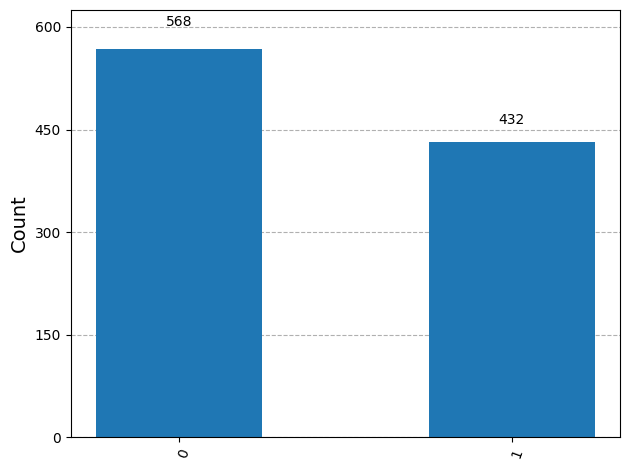

In [20]:
statistics = v.sample_counts(1000)
plot_histogram(statistics)

**So, among 1000 trials:**

*   About 556 should be outcome `0`

*   About 444 should be outcome `1`

**📌 This illustrates the Law of Large Numbers:** The more trials you simulate, the closer the relative frequencies will get to the true probabilities.

## **⚙️ Quantum State Evolution with Operator and Statevector (Qiskit):**

In this section, we learn how to:

*   Define **unitary gates** as operators

*   Use the `.evolve()` method to apply those operations on a quantum state vector

*   Visualize the evolution of the state




### **Imports:**


---


Make sure you import the necessary components first:

In [21]:
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt
from IPython.display import display

### **1. Define Quantum Operators (Unitary Gates):**


---



In [22]:
# Pauli-Y gate
Y = Operator([[0, -1.0j], [1.0j, 0]])

# Hadamard gate
H = Operator([[1 / sqrt(2), 1 / sqrt(2)],
              [1 / sqrt(2), -1 / sqrt(2)]])

# Phase (S) gate
S = Operator([[1, 0],
              [0, 1.0j]])

# T gate (pi/8 gate)
T = Operator([[1, 0],
              [0, (1 + 1.0j) / sqrt(2)]])


**🔍 Optional: Visualize the T Gate**

In [23]:
display(T.draw("latex"))

<IPython.core.display.Latex object>

### **2. Apply Unitary Operations to a Statevector:**


---


We start from the quantum state ∣0⟩=[1,0] and apply a sequence of unitary transformations:

In [24]:
v = Statevector([1, 0])  # Initial state |0⟩

# Apply H → T → H → S → Y
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

# Visualize final state
display(v.draw("latex"))


<IPython.core.display.Latex object>

### **📎 Summary:**

---


| Method | Purpose |
|--------|---------|
| `Operator([...])` | Define a unitary operation (quantum gate) |
| `.draw("latex")` | Visualize the operator or state vector |
| `.evolve(...)` | Apply a quantum gate (unitary operator) to a quantum state |
| `Statevector([...])` | Define a quantum state manually |


---



## **🔄 Quantum State Evolution via QuantumCircuit in Qiskit:**

*   This mini-project summarizes how to:

*   Build a quantum circuit from unitary gates

*   Visualize the circuit

*   Extract its equivalent unitary matrix

*   Evolve an initial state through this circuit

*   Simulate measurement results

### **1. Build the Quantum Circuit**


---


📌 Gates used:

*   `H` – Hadamard gate
*   `T` – π/8 gate
*   `S` – Phase gate
*   `Y` – Pauli-Y gate












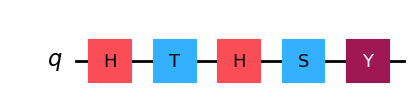

In [25]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from IPython.display import display

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Apply a sequence of gates
circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

# Visualize the circuit
display(circuit.draw(output="mpl"))

### **2. Get the Corresponding Unitary Matrix:**


---

This is useful for verifying logic gates, debugging, or proving circuit equivalence.

In [26]:
# Get the unitary matrix of the full circuit
unitary = Operator.from_circuit(circuit)
display(unitary.draw("latex"))

<IPython.core.display.Latex object>

### **3. Apply the Circuit to a Quantum State:**


---



In [27]:
# Start from |0⟩
ket0 = Statevector([1, 0])

# Evolve through the circuit
v = ket0.evolve(circuit)

# Display the resulting statevector
display(v.draw("latex"))

<IPython.core.display.Latex object>

### **4. Simulate Measurements:**


---



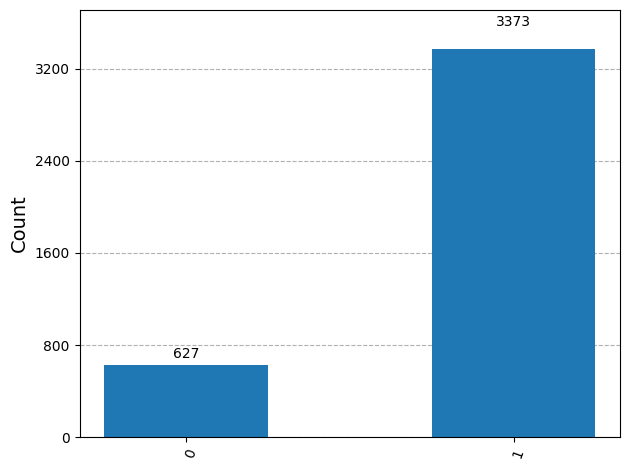

In [28]:
# Simulate 4000 measurements
statistics = v.sample_counts(4000)

# Plot histogram of outcomes
plot_histogram(statistics)